## Generate a small fake dataset

shaped in a way that's hard to separate with a straight line, and get it into the format PyTorch expects

In [8]:
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

`X` = the actual coordinates of those 300 dots (each dot has an x and y position → 2 numbers per dot).

`y` = the correct label for each dot (0 or 1 — which moon it belongs to).

In [9]:
X, y = make_moons(n_samples=300, noise = 0.2, random_state=42)

We convert both from plain NumPy arrays into `torch.tensors` because PyTorch's math operations only work on tensors, not NumPy arrays directly.

In [10]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

"""
unsqueeze:
- without it, the shape would be (300,); just a flat list of numbers. no cols {[0, 1, 1, 0, ...]}
- with it, (300, 1). 300 rows each with 1 col (vertical stacking; 2D matrix) {[[0], [1], [1], [0], ...]}
- one preds per data point
"""

'\nunsqueeze:\n- without it, the shape would be (300,); just a flat list of numbers. no cols {[0, 1, 1, 0, ...]}\n- with it, (300, 1). 300 rows each with 1 col (vertical stacking; 2D matrix) {[[0], [1], [1], [0], ...]}\n- one preds per data point\n'

In [11]:
print(X.shape, y.shape)

torch.Size([300, 2]) torch.Size([300, 1])


X shape: torch.Size([300, 2])
y shape: torch.Size([300, 1])

First 5 rows of X:
 tensor([[ 0.8039, -0.2914],
        [ 2.3144, -0.1222],
        [-0.2804,  0.4509],
        [ 0.7894,  0.3841],
        [ 1.1867, -0.5114]])

First 5 labels:
 tensor([[1.],
        [1.],
        [1.],
        [0.],
        [1.]])

Class balance: (array([0., 1.], dtype=float32), array([150, 150]))


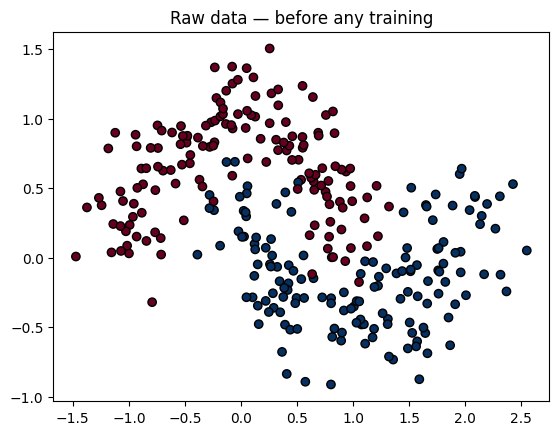

In [12]:
print("X shape:", X.shape)      # (300, 2) - 300 points, 2 coordinates each
print("y shape:", y.shape)      # (300, 1)
print("\nFirst 5 rows of X:\n", X[:5])
print("\nFirst 5 labels:\n", y[:5])
print("\nClass balance:", np.unique(y.numpy(), return_counts=True))

plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="RdBu", edgecolors="k")
plt.title("Raw data - before any training")
plt.show()

A neural network needs two things before it can learn anything: examples and answers (i.e. "here's a data point, here's what it should be classified as"). This above step doesn't build the network yet — it just prepares those examples.

`make_moons` invents 300 fake data points arranged as two crescent moon shapes.
Each dots are moons. The dots are curved and interleaved rather than cleanly separated by a straight line.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

## Build the network

In [14]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 32)   # input: 2 numbers (x, y coords) -> 8 hidden features
        self.layer2 = nn.Linear(32, 1)   # 32 hidden features -> 1 output (probability of class 1)
        self.relu = nn.ReLU() # non-linearity
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      x = self.layer1(x)   # <- pass through the first linear layer
      x = self.relu(x)
      x = self.layer2(x)   # <- pass through the second linear layer
      x = self.sigmoid(x)
      return x

model = SimpleNet()

In [15]:
print(model)

SimpleNet(
  (layer1): Linear(in_features=2, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


`layer1` takes each dot's 2 coordinates and expands them into 8 numbers — think of this as the network inventing 8 different "features" or "questions" about the point

`relu` throws away negative values — this is what lets the network learn curved, non-straight-line patterns (without it, stacking linear layers would mathematically collapse into just one big linear layer, incapable of bending around the moon shapes).

---

**Non-linearity** means the relationship between input and output cannot be drawn as a single straight line, allowing the network to learn complex curves, bends, and decision boundaries.

`layer2` takes those 8 features and boils them down to a single number.

`sigmoid` squashes that number into a 0–1 range, so it can be read as "probability of this point is class 1."

## Train it

1. forward pass   → input flows through layer1 → ReLU → layer2 → sigmoid → prediction
2. loss           → compare prediction vs true label → one number ("how wrong")
3. zero_grad()    → clear leftover gradients from the previous round
4. backward()     → walk backward from the loss through every layer, calculating each
                     weight's gradient (its "blame" for the error) using the chain rule —
                     this is what "backpropagation" means
5. step()         → optimizer nudges every weight: new_weight = old_weight − (lr × gradient)
6. repeat

In [16]:
criterion = nn.BCELoss() # binary cross-entropy (for binary class problem)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2) # adjust weight using optimizer to reduce error

for epoch in range(2000):
    outputs = model(X)
    loss = criterion(outputs, y)

    # clear > calculate loss > apply the fix > go backward > restart process

    optimizer.zero_grad() # clear old gradients; make 0 updates to that neuron's weights
    loss.backward() # compute how much each weight contributed to the error (backpropagation)
    optimizer.step() # actually update the weights using those gradients

    if epoch % 100 == 0: # prints after every 40 epochs
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.7309
Epoch 100, Loss: 0.2297
Epoch 200, Loss: 0.1269
Epoch 300, Loss: 0.0895
Epoch 400, Loss: 0.0757
Epoch 500, Loss: 0.0679
Epoch 600, Loss: 0.0613
Epoch 700, Loss: 0.0576
Epoch 800, Loss: 0.0551
Epoch 900, Loss: 0.0532
Epoch 1000, Loss: 0.0517
Epoch 1100, Loss: 0.0506
Epoch 1200, Loss: 0.0498
Epoch 1300, Loss: 0.0490
Epoch 1400, Loss: 0.0484
Epoch 1500, Loss: 0.0478
Epoch 1600, Loss: 0.0474
Epoch 1700, Loss: 0.0469
Epoch 1800, Loss: 0.0465
Epoch 1900, Loss: 0.0462


Zero gradient, with actual numbers

Say one neuron has weight w = 0.1, and it's looking at an input x = -5.

w * x = 0.1 × -5 = -0.5
ReLU(-0.5) = 0 (negative, so clamped)

Now the optimizer tries a tiny nudge: what if w were 0.11 instead?

w * x = 0.11 × -5 = -0.55
ReLU(-0.55) = still 0

The output didn't change at all — still exactly 0, whether w is 0.1 or 0.11. If nudging the weight doesn't change the output even slightly, then that weight has zero effect on the final loss right now. And "how much does this weight affect the loss" is literally the definition of its gradient. No effect → gradient of 0 → the optimizer has nothing to act on → weight never updates → neuron stays dead forever, since the input would need to flip all the way to positive to escape, and nothing is pushing it there anymore.

Debugging of Training code:

1. The neural network was first built with only 8 nodes in hidden layer
2. Afterwards the loss didn't drop after many epochs and remained constant- "loss plateaus and won't move"
3.  The possible reason could be 'Dying ReLU'
    *   during backpropagation, if a neuron's output is 0, its gradient is also 0
    *   if its weights don't change, its output stays negative (still 0 after ReLU) on the next pass too. stuck outputting 0 forever (dead)
    *   because the mechanism that would fix it (the gradient) is exactly the thing that went to zero
    *   with 8 neurons initially, an unlucky initial random weights can make 2-3 neurons go negative for almost every input right from the start, and they die within the first few epochs
    *   Fix: adding extra 24 neurons > more redundancy > additional neurons to do the calculation
4. Epochs 200 > 2000

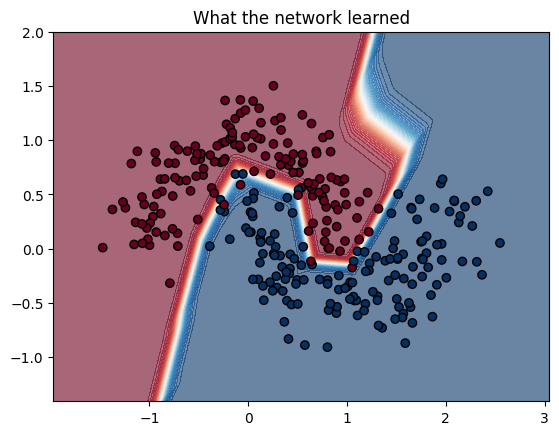

In [17]:
"""
np.meshgrid, .ravel(), np.c_[...], .reshape(xx.shape)
- build and reshape a grid of coordinates
"""

# create a grid covering the data's range
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

"""
asking the model "what would you predict at every point
on this surface," not just your original data points
"""
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

# asking for predictions, not any learning
with torch.no_grad():
    preds = model(grid).reshape(xx.shape)

plt.contourf(xx, yy, preds, levels=50, cmap="RdBu", alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="RdBu", edgecolors="k")
plt.title("What the network learned")
plt.show()